In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

Mounted at /content/drive


In [2]:
base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')
raw_dir = os.path.join(base_dir, 'raw')

part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

In [3]:
# ====================== LOAD CSV ======================
train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

class_names = np.load(os.path.join(base_dir, 'class_names.npy'), allow_pickle=True).tolist()

print(f"✅ Load splits thành công!")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes: {class_names}")
print(f"\nCác cột trong train_df: {train_df.columns.tolist()}")

# ====================== XÁC ĐỊNH CỘT QUAN TRỌNG ======================
image_col = 'image_id'
label_col = 'dx'
print(f"→ Sử dụng cột ảnh: '{image_col}' | cột nhãn: '{label_col}'")

# ====================== THÊM ĐUÔI .jpg + TẠO ĐƯỜNG DẪN ĐẦY ĐỦ ======================
for df in [train_df, val_df, test_df]:
    # Thêm đuôi .jpg nếu chưa có
    df[image_col] = df[image_col].astype(str).apply(lambda x: x if x.lower().endswith('.jpg') else x + '.jpg')

    # Ưu tiên dùng cột image_path nếu có và hợp lệ, ngược lại tự tìm trong 2 part
    if 'image_path' in df.columns:
        df['full_path'] = df['image_path'].where(df['image_path'].notna() & df['image_path'].astype(str).str.contains('HAM10000_images'), None)

    # Nếu chưa có full_path hợp lệ thì tìm trong part_1 và part_2
    def find_image_path(img_name):
        for part_dir in [part1_dir, part2_dir]:
            path = os.path.join(part_dir, img_name)
            if os.path.exists(path):
                return path
        return None

    mask = df.get('full_path', pd.Series([None]*len(df))).isnull()
    df.loc[mask, 'full_path'] = df.loc[mask, image_col].apply(find_image_path)

# Kiểm tra ảnh bị thiếu
missing_train = train_df['full_path'].isnull().sum()
if missing_train > 0:
    print(f"⚠️ Cảnh báo: {missing_train} ảnh trong train không tìm thấy!")

✅ Load splits thành công!
Train: 7010 | Val: 1502 | Test: 1503
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Các cột trong train_df: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label', 'image_path']
→ Sử dụng cột ảnh: 'image_id' | cột nhãn: 'dx'


✅ Train: 7010 | Val: 1502 | Test: 1503
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


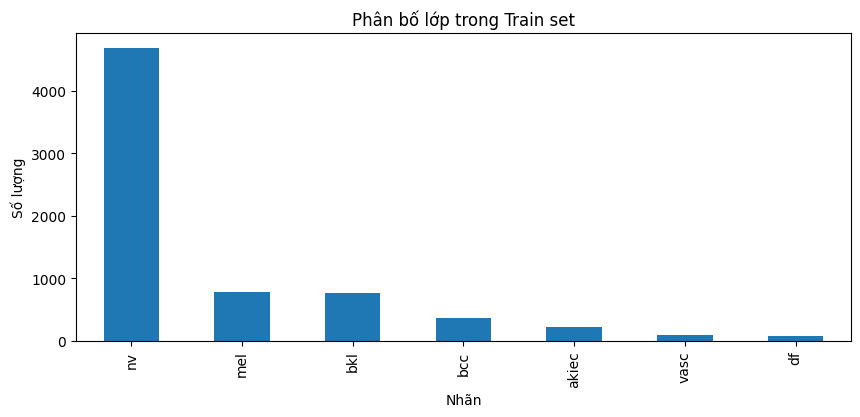

In [4]:
print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Kiểm tra class distribution
plt.figure(figsize=(10,4))
train_df['dx'].value_counts().plot(kind='bar')
plt.title('Phân bố lớp trong Train set')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

In [5]:
# ====================== DATA AUGMENTATION + CLASS WEIGHTING ======================
# Selective augmentation sẽ được áp dụng ở PyTorch Dataset (cell sau),
# còn ImageDataGenerator ở đây để kiểm tra nhanh dữ liệu với mức augment nhẹ.
class_counts = train_df[label_col].value_counts().sort_index()
rare_threshold = 800
rare_classes = class_counts[class_counts <= rare_threshold].index.tolist()

print(f"Ngưỡng lớp hiếm: <= {rare_threshold} mẫu")
print(f"Các lớp hiếm được bật selective augmentation: {rare_classes}")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32
img_size = (224, 224)

# ====================== TẠO GENERATORS ======================
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ====================== LIGHTWEIGHT CLASS WEIGHT ======================
# Không dùng weight balanced "quá tay"; dùng nghịch đảo tần suất đã làm mượt bằng căn bậc hai + clipping.
freq = class_counts.astype(float)
inv_freq = freq.max() / freq
smoothed_weights = np.sqrt(inv_freq)
smoothed_weights = smoothed_weights / smoothed_weights.mean()
smoothed_weights = smoothed_weights.clip(lower=0.75, upper=3.20)

# Y tế da liễu: tăng nhẹ MEL để giảm false negative.
if 'mel' in smoothed_weights.index:
    smoothed_weights.loc['mel'] = min(3.20, smoothed_weights.loc['mel'] * 1.15)

smoothed_weights = smoothed_weights / smoothed_weights.mean()
class_weight_by_label = smoothed_weights.to_dict()

# Map theo thứ tự class_names để dùng cho loss
class_weight_dict = {
    i: float(class_weight_by_label.get(cls, 1.0))
    for i, cls in enumerate(class_names)
}

Ngưỡng lớp hiếm: <= 800 mẫu
Các lớp hiếm được bật selective augmentation: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'vasc']
Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [6]:
print("\n📊 Class weights (lightweight, smoothed):")
for i, w in class_weight_dict.items():
    cls_name = class_names[i] if i < len(class_names) else f"Class_{i}"
    count = int(train_df[train_df[label_col] == cls_name].shape[0]) if cls_name in train_df[label_col].values else 0
    rare_tag = "(RARE)" if cls_name in rare_classes else ""
    print(f"  Lớp {i:2d} ({cls_name:>15}) | count={count:4d} | weight={w:.4f} {rare_tag}")

print("\n" + "="*80)
print("✅ CELL 1 HOÀN TẤT!")
print("   • Train: Selective augmentation cho lớp hiếm (mức nhẹ, không bạo lực)")
print("   • Loss: Focal Loss (ưu tiên giảm false negative, đặc biệt MEL)")
print("   • Class Weight: Làm mượt + clipping, không ép cân bằng tuyệt đối")
print("   • Val & Test: Chỉ rescale/normalize")
print("   • Sử dụng cột image_id làm tên ảnh, full_path tự tìm trong part_1 & part_2")
print("\nBạn có thể chạy cell tiếp theo xây dựng mô hình.")

# Bonus: Phân bố lớp trong train
print("\nPhân bố lớp trong Train:")
print(train_df[label_col].value_counts().sort_index())
print(f"\nCác lớp hiếm đã bật selective augmentation: {rare_classes}")


📊 Class weights (lightweight, smoothed):
  Lớp  0 (          akiec) | count= 229 | weight=0.9819 (RARE)
  Lớp  1 (            bcc) | count= 360 | weight=0.7831 (RARE)
  Lớp  2 (            bkl) | count= 769 | weight=0.6637 (RARE)
  Lớp  3 (             df) | count=  81 | weight=1.6510 (RARE)
  Lớp  4 (            mel) | count= 779 | weight=0.7632 (RARE)
  Lớp  5 (             nv) | count=4693 | weight=0.6637 
  Lớp  6 (           vasc) | count=  99 | weight=1.4934 (RARE)

✅ CELL 1 HOÀN TẤT!
   • Train: Selective augmentation cho lớp hiếm (mức nhẹ, không bạo lực)
   • Loss: Focal Loss (ưu tiên giảm false negative, đặc biệt MEL)
   • Class Weight: Làm mượt + clipping, không ép cân bằng tuyệt đối
   • Val & Test: Chỉ rescale/normalize
   • Sử dụng cột image_id làm tên ảnh, full_path tự tìm trong part_1 & part_2

Bạn có thể chạy cell tiếp theo xây dựng mô hình.

Phân bố lớp trong Train:
dx
akiec     229
bcc       360
bkl       769
df         81
mel       779
nv       4693
vasc       99
Na

In [12]:
# ====================== CELL 2: Config + Seed + Device ======================
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.metrics import f1_score
import math
from torch.optim.lr_scheduler import LambdaLR


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

CKPT_DIR = "/content/drive/MyDrive/DA_checkpoints/VGGxViT_v5"
os.makedirs(CKPT_DIR, exist_ok=True)

CFG = {
    "img_size": 224,
    "num_classes": 7,
    "batch_phaseA": 32,
    "batch_phaseB": 24,
    "epochsA": 30,
    "epochsB": 40,
    "lr_headA": 4e-4,
    "lr_backboneB": 1e-5,
    "lr_headB": 1e-5,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "warmup_ratio": 0.1,
    "grad_clip": 1.0,
    "use_amp": True,
    "rare_aug_prob": 0.75,
    "focal_gamma": 2.0,
    "focal_eps": 1e-8
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

✅ Device: cuda


In [8]:
import torch.nn as nn
import torch
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class HAM10000Dataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        label_col='dx',
        class_to_idx=None,
        rare_classes=None,
        rare_transform=None,
        rare_aug_prob=0.0
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
        self.rare_transform = rare_transform
        self.rare_classes = set(rare_classes) if rare_classes is not None else set()
        self.rare_aug_prob = rare_aug_prob

        if class_to_idx is None:
            unique_labels = sorted(df[label_col].unique())
            self.class_to_idx = {cls: idx for idx, cls in enumerate(unique_labels)}
        else:
            self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')

        label_name = row[self.label_col]
        label = self.class_to_idx[label_name]

        # Selective augmentation: chỉ augment cho lớp hiếm, với xác suất vừa phải.
        use_rare_aug = (
            label_name in self.rare_classes
            and self.rare_transform is not None
            and np.random.rand() < self.rare_aug_prob
        )

        if use_rare_aug:
            image = self.rare_transform(image)
        elif self.transform:
            image = self.transform(image)

        return image, label


# Transforms nền (không bạo lực)
train_base_tfms = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Augmentation nhẹ cho lớp hiếm
rare_train_tfms = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dùng mapping cố định theo class_names để tránh lệch index giữa train/val/test
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

# Tạo Dataset & Loader
train_dataset = HAM10000Dataset(
    train_df,
    transform=train_base_tfms,
    label_col=label_col,
    class_to_idx=class_to_idx,
    rare_classes=rare_classes,
    rare_transform=rare_train_tfms,
    rare_aug_prob=CFG["rare_aug_prob"]
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=val_tfms,
    label_col=label_col,
    class_to_idx=class_to_idx
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=val_tfms,
    label_col=label_col,
    class_to_idx=class_to_idx
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_phaseA"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_phaseA"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG["batch_phaseA"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"✅ Rare classes (selective aug): {rare_classes}")
print(f"✅ Rare augmentation probability: {CFG['rare_aug_prob']}")

✅ Train batches: 220 | Val: 47 | Test: 47
✅ Rare classes (selective aug): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'vasc']
✅ Rare augmentation probability: 0.75


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16


# ---------------------------
# small helper conv block: Conv2d -> BN -> ReLU
# ---------------------------
def conv_bn_relu(in_c, out_c, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )


# ---------------------------
# Pretrained VGG16 feature extractor (up to pool3)
# ---------------------------
class VGG16Blocks(nn.Module):
    def __init__(self, pretrained=True, to_pool3=True):
        """
        to_pool3=True -> use features up to pool3 (more semantic features): output channels = 256, spatial 28x28
        """
        super().__init__()
        vgg = vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        if to_pool3:
            # children() slice to include layers up to pool3 (index 17)
            self.features = nn.Sequential(*list(vgg.features.children())[:17])  # conv.. -> pool3
            self.out_channels = 256
        else:
            # keep original behavior (pool2)
            self.features = nn.Sequential(*list(vgg.features.children())[:10])  # conv.. -> pool2
            self.out_channels = 128

    def forward(self, x):
        return self.features(x)  # [B, out_channels, H, W]


# ---------------------------
# Inception v7 block (improved: BN + ReLU in all convs)
# ---------------------------
class InceptionV7(nn.Module):
    def __init__(self, in_channels=256, out_channels=512, branch_channels=128, dropout=0.0):
        """
        in_channels: channels from previous layer (e.g., 256 if using pool3)
        out_channels: final projected channels (e.g., 512)
        branch_channels: intermediate channels per branch (128 typical)
        """
        super().__init__()
        b = branch_channels

        # Branch 1: 1x1
        self.branch1 = conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0)

        # Branch 2: 1x1 -> (3x1) -> (1x3)
        self.branch2 = nn.Sequential(
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
        )

        # Branch 3: 1x1 -> (3x1+1x3) -> (3x1+1x3)
        self.branch3 = nn.Sequential(
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
        )

        # Branch 4: MaxPool 3x3 (stride 1 pad1) -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0)
        )

        # Project concatenated branches to out_channels
        self.proj = conv_bn_relu(b * 4, out_channels, kernel_size=1, stride=1, padding=0)

        # Optional dropout on output of inception
        self.dropout = nn.Dropout2d(p=dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x4 = self.branch4(x)
        out = torch.cat([x1, x2, x3, x4], dim=1)
        out = self.proj(out)
        out = self.dropout(out)
        return out  # [B, out_channels, H, W]


# ---------------------------
# Reduce spatial dims to reduce token count (Conv stride)
# ---------------------------
class SpatialReducer(nn.Module):
    def __init__(self, in_channels=512, out_channels=512, stride=4):
        """
        Reduce HxW by stride (e.g., 28->7 when stride=4).
        """
        super().__init__()
        self.reduce = conv_bn_relu(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)

    def forward(self, x):
        return self.reduce(x)  # [B, out_channels, H//stride, W//stride]


# ---------------------------
# Patch Encoder + Positional Embedding
# ---------------------------
class PatchEncoder(nn.Module):
    def __init__(self, in_c=512, emb_dim=32, grid_size=(7, 7)):
        super().__init__()
        self.in_c = in_c
        self.emb_dim = emb_dim
        self.grid_h, self.grid_w = grid_size
        self.num_patches = self.grid_h * self.grid_w
        self.proj = nn.Linear(in_c, emb_dim)
        # learnable pos emb
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, emb_dim) * 0.02)

    def forward(self, x):
        # x: [B, C, H, W] where H=W=grid_size
        B, C, H, W = x.shape
        assert H == self.grid_h and W == self.grid_w, f"Expected grid {self.grid_h}x{self.grid_w}, got {H}x{W}"
        x = x.permute(0, 2, 3, 1).reshape(B, H * W, C)  # [B, N, C]
        x = self.proj(x)  # [B, N, emb_dim]
        x = x + self.pos_embed  # add positional embedding
        return x  # [B, N, emb_dim]


# ---------------------------
# ViT Encoder (configurable)
# ---------------------------
class ViTEncoder(nn.Module):
    def __init__(self, emb_dim=32, depth=6, heads=4, mlp_dim=128, dropout=0.1):
        super().__init__()
        # ensure emb_dim divisible by heads
        assert emb_dim % heads == 0, "emb_dim must be divisible by heads"
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_dim,
                nhead=heads,
                dim_feedforward=mlp_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            ) for _ in range(depth)
        ])
        self.final_norm = nn.LayerNorm(emb_dim)

    def forward(self, x):
        # x: [B, N, emb_dim]
        for layer in self.layers:
            x = layer(x)
        x = self.final_norm(x)
        return x  # [B, N, emb_dim]


# ---------------------------
# Attention Pooling (weighted sum of tokens)
# ---------------------------
class AttentionPool(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.attn = nn.Linear(emb_dim, 1)

    def forward(self, x):
        # x: [B, N, emb_dim]
        scores = self.attn(x)         # [B, N, 1]
        weights = torch.softmax(scores, dim=1)  # [B, N, 1]
        pooled = (x * weights).sum(dim=1)  # [B, emb_dim]
        return pooled


# ---------------------------
# Full PlantXViT v2 (optimized)
# ---------------------------
class PlantXViT_v2(nn.Module):
    def __init__(
        self,
        num_classes=8,
        emb_dim=32,
        pretrained_vgg=True,
        use_pool3=True,
        inception_out_channels=512,
        reducer_stride=4,
        vit_depth=6,
        vit_heads=4,
        vit_mlp=128,
        vit_dropout=0.1,
        classifier_dropout=0.3
    ):
        super().__init__()

        # 1) VGG blocks (pretrained). By default use up to pool3 for richer features
        self.vgg = VGG16Blocks(pretrained=pretrained_vgg, to_pool3=use_pool3)
        vgg_out_c = self.vgg.out_channels  # 256 if pool3, else 128

        # 2) Inception block (take vgg_out_c -> inception_out_channels)
        self.inception = InceptionV7(in_channels=vgg_out_c, out_channels=inception_out_channels, branch_channels=128, dropout=0.0)

        # 3) spatial reducer to shrink patch grid (e.g., 28->7 with stride=4)
        self.reducer = SpatialReducer(in_channels=inception_out_channels, out_channels=inception_out_channels, stride=reducer_stride)
        # calculate grid size after reduction: if input 28 and stride 4 -> 7
        # We'll set grid_size = (H_after, W_after)
        # For standard 224 input and pool3 -> 28 -> stride4 -> 7
        grid_size = (7, 7)

        # 4) Patch encoder + positional embeddings
        self.patch_encoder = PatchEncoder(in_c=inception_out_channels, emb_dim=emb_dim, grid_size=grid_size)

        # 5) ViT encoder
        self.transformer = ViTEncoder(emb_dim=emb_dim, depth=vit_depth, heads=vit_heads, mlp_dim=vit_mlp, dropout=vit_dropout)

        # 6) Pooling (attention) + classifier head
        self.attn_pool = AttentionPool(emb_dim)
        self.norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # x: [B, 3, 224, 224]
        x = self.vgg(x)              # [B, vgg_out_c, Hv, Wv] e.g., [B,256,28,28]
        x = self.inception(x)        # [B, inception_out, Hv, Wv] e.g., [B,512,28,28]
        x = self.reducer(x)          # [B, inception_out, Hr, Wr] e.g., [B,512,7,7]
        x = self.patch_encoder(x)    # [B, N=49, emb_dim]
        x = self.transformer(x)      # [B, N, emb_dim]
        x = self.attn_pool(x)        # [B, emb_dim]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.classifier(x)       # [B, num_classes]
        return x


# ---------------------------
# Quick test
# ---------------------------
if __name__ == "__main__":
    model = PlantXViT_v2(
        num_classes=7,
        emb_dim=32,
        pretrained_vgg=True,
        use_pool3=True,
        inception_out_channels=512,
        reducer_stride=4,
        vit_depth=6,
        vit_heads=4,
        vit_mlp=128,
        vit_dropout=0.1,
        classifier_dropout=0.3
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    x = torch.randn(2, 3, 224, 224).to(device)
    y = model(x)
    print("Output shape:", y.shape)
    print("Total parameters:", sum(p.numel() for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 188MB/s]


Output shape: torch.Size([2, 7])
Total parameters: 4882120


In [10]:
import math
from torch.optim.lr_scheduler import LambdaLR

def get_cosine_with_warmup(optimizer, warmup_steps, total_steps, last_epoch=-1):
    """Cosine decay with linear warmup; scheduler.step() is expected to be called every iteration (batch).
    last_epoch is the number of steps already taken (for resume).
    """
    warmup_steps = int(max(0, warmup_steps))
    total_steps = int(max(1, total_steps))
    warmup_steps = min(warmup_steps, total_steps)

    def lr_lambda(step):
        step = int(step)
        if warmup_steps > 0 and step < warmup_steps:
            return step / max(1, warmup_steps)
        if total_steps == warmup_steps:
            return 1.0
        progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return LambdaLR(optimizer, lr_lambda, last_epoch=last_epoch)

In [11]:
from torch.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.metrics import f1_score
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler(enabled=CFG["use_amp"])


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction="mean", eps=1e-8):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction
        self.eps = eps

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        pt = torch.exp(-ce_loss).clamp(min=self.eps, max=1.0)
        focal_factor = (1.0 - pt) ** self.gamma
        loss = focal_factor * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def build_alpha_tensor(class_weight_dict, num_classes, device):
    alpha_values = [float(class_weight_dict.get(i, 1.0)) for i in range(num_classes)]
    return torch.tensor(alpha_values, dtype=torch.float32, device=device)


def train_one_epoch(model, loader, optimizer, criterion, device, epoch_num, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, desc=f"Train Epoch {epoch_num+1}", leave=True):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast(device_type='cuda', enabled=CFG["use_amp"]):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        if torch.isnan(loss):
            print("❌ NaN loss detected, skipping batch...")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, labels_all = [], []

    for imgs, labels in tqdm(loader, desc="Valid", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type='cuda', enabled=CFG["use_amp"]):
            out = model(imgs)
            loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds.append(out.argmax(1).cpu().numpy())
        labels_all.append(labels.cpu().numpy())

    preds = np.concatenate(preds)
    labels_all = np.concatenate(labels_all)
    acc = (preds == labels_all).mean()
    f1 = f1_score(labels_all, preds, average="macro")
    return total_loss / len(loader.dataset), acc, f1

In [ ]:
# ====================== TRAINING STRATEGY (RECOMMENDED): Staged Unfreezing + Discriminative LR ======================
# Mục tiêu: ổn định hơn 2-phase đơn giản và thường cho macro-F1 tốt hơn với dữ liệu lệch lớp như HAM10000.
# Chạy cell này THAY cho Phase A/B ở dưới nếu bạn muốn chiến thuật tốt hơn.

import os
import torch

# 0) Khởi tạo model nếu chưa có
if 'model' not in locals():
    model = PlantXViT_v2(num_classes=CFG["num_classes"]).to(device)
print("✅ Model ready")

# 1) Helper: set requires_grad theo prefix module (vgg/inception/reducer/patch_encoder/transformer/attn_pool/norm/classifier)
def set_trainable_prefixes(model, prefixes):
    prefixes = tuple(prefixes)
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith(prefixes)


def build_stage_optimizer(model, lrs, weight_decay):
    """Tạo optimizer theo nhóm module với LR phân tầng. Chỉ lấy params có requires_grad=True."""
    param_groups = []

    def add_group(module, lr):
        params = [p for p in module.parameters() if p.requires_grad]
        if params:
            param_groups.append({"params": params, "lr": float(lr)})

    # CNN backbone
    add_group(model.vgg, lrs.get("vgg", 0.0))
    add_group(model.inception, lrs.get("inception", 0.0))
    add_group(model.reducer, lrs.get("reducer", 0.0))
    # Tokenizer + Transformer
    add_group(model.patch_encoder, lrs.get("patch_encoder", 0.0))
    add_group(model.transformer, lrs.get("transformer", 0.0))
    # Head
    add_group(model.attn_pool, lrs.get("head", 0.0))
    add_group(model.norm, lrs.get("head", 0.0))
    add_group(model.classifier, lrs.get("head", 0.0))

    if len(param_groups) == 0:
        raise ValueError("No trainable parameters found for this stage")

    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


def run_staged_training(stages, ckpt_prefix="PlantXViT_staged", patience=6):
    steps_per_epoch = len(train_loader)
    best = {"f1": -1.0, "acc": -1.0}
    bad_epochs = 0

    alpha_tensor = build_alpha_tensor(class_weight_dict, CFG["num_classes"], device)
    criterion = FocalLoss(
        alpha=alpha_tensor,
        gamma=CFG["focal_gamma"],
        label_smoothing=CFG["label_smoothing"],
        eps=CFG["focal_eps"]
    )

    for s_idx, st in enumerate(stages, start=1):
        print("\n" + "=" * 90)
        print(f"▶ Stage {s_idx}/{len(stages)}: {st['name']} | epochs={st['epochs']}")
        print(f"  Trainable: {st['trainable']}")
        print(f"  LRs: {st['lrs']}")

        # set trainable
        set_trainable_prefixes(model, st["trainable"])
        optimizer = build_stage_optimizer(model, st["lrs"], CFG["weight_decay"])

        total_steps = steps_per_epoch * st["epochs"]
        warmup_steps = int(total_steps * CFG["warmup_ratio"])
        scheduler = get_cosine_with_warmup(optimizer, warmup_steps, total_steps)

        for ep in range(st["epochs"]):
            epoch_num = ep  # hiển thị epoch trong stage
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch_num, scheduler)
            val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

            # in LR của nhóm đầu (thường là module đầu tiên trong stage)
            lr_show = optimizer.param_groups[0]["lr"]
            print(f"[{st['name']}][Epoch {ep+1}/{st['epochs']}] "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | F1: {val_f1:.3f} | "
                  f"LR: {lr_show:.2e}")

            is_best = False
            if (val_f1 > best["f1"]) or (val_f1 == best["f1"] and val_acc > best["acc"]):
                best["f1"] = float(val_f1)
                best["acc"] = float(val_acc)
                is_best = True
                bad_epochs = 0
                print(f"🔥 BEST UPDATE => F1={best['f1']:.3f} | Acc={best['acc']:.3f}")
            else:
                bad_epochs += 1

            state = {
                "stage": st["name"],
                "stage_index": s_idx,
                "epoch_in_stage": ep + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_f1": best["f1"],
                "best_val_acc": best["acc"]
            }

            torch.save(state, os.path.join(CKPT_DIR, f"{ckpt_prefix}_last.pth"))
            if is_best:
                torch.save(state, os.path.join(CKPT_DIR, f"{ckpt_prefix}_best.pth"))

            if patience is not None and bad_epochs >= patience:
                print(f"⏹ Early stopping triggered (no improvement for {patience} val epochs)")
                return best

    return best


stages = [
    # Stage 1: chỉ train head (ổn định, ít overfit nhanh)
    {
        "name": "S1_head",
        "epochs": 5,
        "trainable": ["attn_pool", "norm", "classifier"],
        "lrs": {"head": 4e-4}
    },
    # Stage 2: unfreeze phần Transformer + patch encoder
    {
        "name": "S2_vit",
        "epochs": 10,
        "trainable": ["patch_encoder", "transformer", "attn_pool", "norm", "classifier"],
        "lrs": {"patch_encoder": 2e-4, "transformer": 2e-4, "head": 3e-4}
    },
    # Stage 3: unfreeze Inception/Reducer (CNN mid-level), vẫn giữ VGG frozen để tránh phá feature pretrained
    {
        "name": "S3_midcnn",
        "epochs": 10,
        "trainable": ["inception", "reducer", "patch_encoder", "transformer", "attn_pool", "norm", "classifier"],
        "lrs": {"inception": 1e-4, "reducer": 1e-4, "patch_encoder": 1.5e-4, "transformer": 1.5e-4, "head": 2.5e-4}
    },
    # Stage 4: fine-tune toàn bộ (LR rất nhỏ cho VGG)
    {
        "name": "S4_full",
        "epochs": 12,
        "trainable": ["vgg", "inception", "reducer", "patch_encoder", "transformer", "attn_pool", "norm", "classifier"],
        "lrs": {"vgg": 1e-5, "inception": 3e-5, "reducer": 3e-5, "patch_encoder": 8e-5, "transformer": 8e-5, "head": 1.5e-4}
    }
]

best = run_staged_training(stages, ckpt_prefix="PlantXViT_staged", patience=6)
print("\n✅ DONE. Best:", best)

✅ Model ready

▶ Stage 1/4: S1_head | epochs=5
  Trainable: ['attn_pool', 'norm', 'classifier']
  LRs: {'head': 0.0004}


Train Epoch 1: 100%|██████████| 220/220 [16:01<00:00,  4.37s/it]


[S1_head][Epoch 1/5] Train Loss: 0.7496 | Train Acc: 0.522 | Val Loss: 0.6171 | Val Acc: 0.658 | F1: 0.121 | LR: 3.88e-04
🔥 BEST UPDATE => F1=0.121 | Acc=0.658


Train Epoch 2: 100%|██████████| 220/220 [01:33<00:00,  2.36it/s]


[S1_head][Epoch 2/5] Train Loss: 0.5911 | Train Acc: 0.668 | Val Loss: 0.6335 | Val Acc: 0.662 | F1: 0.127 | LR: 3.00e-04
🔥 BEST UPDATE => F1=0.127 | Acc=0.662


...

[S4_full][Epoch 10/12] Train Loss: 0.0779 | Train Acc: 0.949 | Val Loss: 0.3286 | Val Acc: 0.833 | F1: 0.680 | LR: 8.23e-07


Train Epoch 11: 100%|██████████| 220/220 [01:43<00:00,  2.12it/s]


[S4_full][Epoch 11/12] Train Loss: 0.0798 | Train Acc: 0.950 | Val Loss: 0.3029 | Val Acc: 0.838 | F1: 0.700 | LR: 2.10e-07
🔥 BEST UPDATE => F1=0.700 | Acc=0.838


Train Epoch 12: 100%|██████████| 220/220 [01:49<00:00,  2.01it/s]


[S4_full][Epoch 12/12] Train Loss: 0.0737 | Train Acc: 0.954 | Val Loss: 0.3153 | Val Acc: 0.836 | F1: 0.692 | LR: 0.00e+00

✅ DONE. Best: {'f1': 0.6999990545202618, 'acc': 0.8375499334221038}


In [13]:
# Phase A — Freeze 2 block đầu của VGG16 để tránh phá backbone, nhưng vẫn cho block3 adapt nhẹ
steps_per_epoch = len(train_loader)

def freeze_vgg_first_n_blocks(vgg_module, freeze_blocks=2):
    """Freeze theo block của VGG features.
    block1: idx [0..4], block2: [5..9], block3: [10..16] (vì bạn đang dùng VGG đến pool3).
    freeze_blocks=2 => freeze block1+2, chỉ train block3.
    """
    # cutoff index (exclusive) để freeze toàn bộ layer trước cutoff
    cutoff_by_blocks = {0: 0, 1: 5, 2: 10, 3: 17}
    cutoff = cutoff_by_blocks.get(int(freeze_blocks), 10)
    for i, layer in enumerate(vgg_module.features):
        trainable = (i >= cutoff)
        for p in layer.parameters():
            p.requires_grad = trainable

# Freeze 2 blocks đầu (khuyến nghị cho Phase A)
freeze_vgg_first_n_blocks(model.vgg, freeze_blocks=2)

alpha_tensor = build_alpha_tensor(class_weight_dict, CFG["num_classes"], device)
criterion = FocalLoss(
    alpha=alpha_tensor,
    gamma=CFG["focal_gamma"],
    label_smoothing=CFG["label_smoothing"],
    eps=CFG["focal_eps"]
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_headA"],
    weight_decay=CFG["weight_decay"]
)

total_steps = len(train_loader) * CFG["epochsA"]
warmup_steps = int(total_steps * CFG["warmup_ratio"])
scheduler = get_cosine_with_warmup(optimizer, warmup_steps, total_steps)

best_val_acc = 0.0
best_val_f1 = 0.0

for epoch in range(CFG["epochsA"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, scheduler)
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

    print(f"[Phase A][Epoch {epoch+1}/{CFG['epochsA']}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | F1: {val_f1:.3f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    is_best = False
    # Ưu tiên macro-F1 (imbalanced), hoà thì dùng acc
    if (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and val_acc > best_val_acc):
        best_val_f1 = val_f1
        best_val_acc = val_acc
        is_best = True
        print(f"🔥 New best model found (Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f})")

    state = {
        "epoch": epoch + 1,
        "global_step": (epoch + 1) * steps_per_epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1
    }

    torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_phaseA.pth"))
    if is_best:
        torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_best.pth"))

Train Epoch 1: 100%|██████████| 220/220 [21:59<00:00,  6.00s/it]


[Phase A][Epoch 1/30] Train Loss: 0.4837 | Train Acc: 0.713 | Val Loss: 0.5157 | Val Acc: 0.672 | F1: 0.263 | LR: 1.33e-04
🔥 New best model found (Val F1: 0.263 | Val Acc: 0.672)


Train Epoch 2: 100%|██████████| 220/220 [01:38<00:00,  2.24it/s]


[Phase A][Epoch 2/30] Train Loss: 0.3278 | Train Acc: 0.795 | Val Loss: 0.4692 | Val Acc: 0.689 | F1: 0.217 | LR: 2.67e-04


Train Epoch 3: 100%|██████████| 220/220 [01:35<00:00,  2.31it/s]


...

[Phase A][Epoch 28/30] Train Loss: 0.0313 | Train Acc: 0.986 | Val Loss: 0.2084 | Val Acc: 0.869 | F1: 0.777 | LR: 5.39e-06
🔥 New best model found (Val F1: 0.777 | Val Acc: 0.869)


Train Epoch 29: 100%|██████████| 220/220 [01:41<00:00,  2.17it/s]


[Phase A][Epoch 29/30] Train Loss: 0.0286 | Train Acc: 0.988 | Val Loss: 0.2067 | Val Acc: 0.871 | F1: 0.775 | LR: 1.35e-06


Train Epoch 30: 100%|██████████| 220/220 [01:37<00:00,  2.25it/s]


[Phase A][Epoch 30/30] Train Loss: 0.0298 | Train Acc: 0.987 | Val Loss: 0.2032 | Val Acc: 0.870 | F1: 0.779 | LR: 0.00e+00
🔥 New best model found (Val F1: 0.779 | Val Acc: 0.870)


In [ ]:
# Phase A (Resume) — Tiếp tục train thêm N epoch (resume đúng scheduler theo step)
import os
import torch

resume_ckpt_path = os.path.join(CKPT_DIR, "PlantXViT_best.pth")
extra_epochs = 30

if not os.path.exists(resume_ckpt_path):
    raise FileNotFoundError(f"❌ Không tìm thấy checkpoint: {resume_ckpt_path}")

if 'model' not in locals():
    model = PlantXViT_v2(num_classes=CFG["num_classes"]).to(device)

def freeze_vgg_first_n_blocks(vgg_module, freeze_blocks=2):
    cutoff_by_blocks = {0: 0, 1: 5, 2: 10, 3: 17}
    cutoff = cutoff_by_blocks.get(int(freeze_blocks), 10)
    for i, layer in enumerate(vgg_module.features):
        trainable = (i >= cutoff)
        for p in layer.parameters():
            p.requires_grad = trainable

# Giữ đúng mục tiêu Phase A: freeze block1+2, train block3
freeze_vgg_first_n_blocks(model.vgg, freeze_blocks=2)

alpha_tensor = build_alpha_tensor(class_weight_dict, CFG["num_classes"], device)
criterion = FocalLoss(
    alpha=alpha_tensor,
    gamma=CFG["focal_gamma"],
    label_smoothing=CFG["label_smoothing"],
    eps=CFG["focal_eps"]
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_headA"],
    weight_decay=CFG["weight_decay"]
)

checkpoint = torch.load(resume_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])

# Load optimizer_state để giữ Adam moments; nếu resume hay tụt, thử bỏ load optimizer_state và giảm LR.
if "optimizer_state" in checkpoint:
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
    except Exception as e:
        print(f"⚠️ Không load được optimizer_state, sẽ dùng optimizer mới. Lý do: {e}")

# Ép lại base LR sau khi load optimizer_state (tránh dính LR rất nhỏ cuối chu kỳ trước)
for pg in optimizer.param_groups:
    pg["lr"] = float(CFG["lr_headA"])

start_epoch = int(checkpoint.get("epoch", 0))
best_val_acc = float(checkpoint.get("best_val_acc", 0.0))
best_val_f1 = float(checkpoint.get("best_val_f1", 0.0))

steps_per_epoch = len(train_loader)
start_step = int(checkpoint.get("global_step", start_epoch * steps_per_epoch))

end_epoch = start_epoch + extra_epochs
total_epochs = end_epoch
total_steps = steps_per_epoch * total_epochs
warmup_steps = int(total_steps * CFG["warmup_ratio"])

# Scheduler không bị reset: resume đúng theo start_step
scheduler = get_cosine_with_warmup(
    optimizer,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
    last_epoch=start_step - 1
)

print(f"Resume from epoch: {start_epoch}")
print(f"Current best Val F1: {best_val_f1:.4f} | Val Acc: {best_val_acc:.4f}")
print(f"Resume global_step: {start_step} / total_steps: {total_steps}")
print(f"Current LR: {optimizer.param_groups[0]['lr']:.2e}")

for epoch in range(start_epoch, end_epoch):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, scheduler)
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

    print(f"[Phase A][Epoch {epoch+1}/{end_epoch}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | F1: {val_f1:.3f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    is_best = False
    if (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and val_acc > best_val_acc):
        best_val_f1 = val_f1
        best_val_acc = val_acc
        is_best = True
        print(f"🔥 New best model found (Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f})")

    state = {
        "epoch": epoch + 1,
        "global_step": (epoch + 1) * steps_per_epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1
    }

    torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_phaseA.pth"))
    if is_best:
        torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_best.pth"))

Resume from epoch: 15
Current best Val Acc: 0.8329


Train Epoch 16: 100%|██████████| 220/220 [01:34<00:00,  2.32it/s]


[Phase A][Epoch 16/45] Train Loss: 0.0323 | Train Acc: 0.989 | Val Loss: 0.2962 | Val Acc: 0.827 | F1: 0.683


Train Epoch 17: 100%|██████████| 220/220 [01:32<00:00,  2.39it/s]


[Phase A][Epoch 17/45] Train Loss: 0.0420 | Train Acc: 0.979 | Val Loss: 0.3786 | Val Acc: 0.780 | F1: 0.638


...

[Phase A][Epoch 25/45] Train Loss: 0.0463 | Train Acc: 0.974 | Val Loss: 0.3691 | Val Acc: 0.817 | F1: 0.643


Train Epoch 26: 100%|██████████| 220/220 [01:30<00:00,  2.42it/s]


[Phase A][Epoch 26/45] Train Loss: 0.0414 | Train Acc: 0.982 | Val Loss: 0.4172 | Val Acc: 0.797 | F1: 0.576


Train Epoch 27:  20%|██        | 45/220 [00:19<01:14,  2.34it/s]


KeyboardInterrupt: 

In [14]:
# Phase B — Fine-tune toàn bộ (discriminative LR)
import os
import torch

ckpt_path = os.path.join(CKPT_DIR, "PlantXViT_best.pth")

if os.path.exists(ckpt_path):
    print(f"Loading model from {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    best_val_acc = float(checkpoint.get("best_val_acc", 0.0))
    best_val_f1 = float(checkpoint.get("best_val_f1", 0.0))
else:
    print("⚠️ No checkpoint found, starting from scratch")
    best_val_acc = 0.0
    best_val_f1 = 0.0

# Unfreeze all
for p in model.parameters():
    p.requires_grad = True

# Param groups: VGG rất nhỏ LR, còn lại lớn hơn
backbone_params = list(model.vgg.parameters())
head_params = [p for n, p in model.named_parameters() if not n.startswith("vgg.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG["lr_backboneB"]},
    {"params": head_params, "lr": CFG["lr_headB"]}
] , weight_decay=CFG["weight_decay"])

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * CFG["epochsB"]
warmup_steps = int(total_steps * CFG["warmup_ratio"])
scheduler = get_cosine_with_warmup(optimizer, warmup_steps, total_steps)

alpha_tensor = build_alpha_tensor(class_weight_dict, CFG["num_classes"], device)
criterion = FocalLoss(
    alpha=alpha_tensor,
    gamma=CFG["focal_gamma"],
    label_smoothing=CFG["label_smoothing"],
    eps=CFG["focal_eps"]
)

for epoch in range(CFG["epochsB"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, scheduler)
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, criterion, device)

    lr_vgg = optimizer.param_groups[0]['lr']
    lr_head = optimizer.param_groups[1]['lr']
    print(f"[Phase B][Epoch {epoch+1}/{CFG['epochsB']}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | F1: {val_f1:.3f} | "
          f"LR(vgg): {lr_vgg:.2e} | LR(head): {lr_head:.2e}")

    is_best = False
    if (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and val_acc > best_val_acc):
        best_val_f1 = val_f1
        best_val_acc = val_acc
        is_best = True
        print(f"🔥 New best model found (Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f})")

    state = {
        "epoch": epoch + 1,
        "global_step": (epoch + 1) * steps_per_epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1
    }

    torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_phaseB.pth"))
    if is_best:
        torch.save(state, os.path.join(CKPT_DIR, "PlantXViT_best.pth"))

Loading model from /content/drive/MyDrive/DA_checkpoints/VGGxViT_v5/PlantXViT_best.pth


Train Epoch 1: 100%|██████████| 220/220 [01:41<00:00,  2.16it/s]


[Phase B][Epoch 1/40] Train Loss: 0.0304 | Train Acc: 0.985 | Val Loss: 0.2112 | Val Acc: 0.868 | F1: 0.767 | LR(vgg): 2.50e-06 | LR(head): 2.50e-06


Train Epoch 2: 100%|██████████| 220/220 [01:42<00:00,  2.15it/s]


[Phase B][Epoch 2/40] Train Loss: 0.0305 | Train Acc: 0.985 | Val Loss: 0.2036 | Val Acc: 0.864 | F1: 0.766 | LR(vgg): 5.00e-06 | LR(head): 5.00e-06


Train Epoch 3: 100%|██████████| 220/220 [01:44<00:00,  2.11it/s]


[Phase B][Epoch 3/40] Train Loss: 0.0301 | Train Acc: 0.987 | Val Loss: 0.2159 | Val Acc: 0.867 | F1: 0.769 | LR(vgg): 7.50e-06 | LR(head): 7.50e-06


Train Epoch 4:  10%|█         | 22/220 [49:05<7:21:51, 133.89s/it]


KeyboardInterrupt: 

In [15]:
import torch
import os

# Đảm bảo model đã được khởi tạo trước (nếu chưa)
if 'model' not in locals():
    model = PlantXViT_v2(num_classes=CFG["num_classes"]).to(device)

ckpt_path = os.path.join(CKPT_DIR, "PlantXViT_best.pth")
if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    print(f"Checkpoint keys: {list(checkpoint.keys())}")
    if "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"], strict=False)  # strict=False nếu có mismatch
        print("Model state loaded successfully")
    else:
        print("No 'model_state' in checkpoint! Check saving logic.")
else:
    print(f"Checkpoint not found at {ckpt_path}")

model.eval()

# Define criterion for evaluation if it's not already defined
if 'criterion' not in locals():
    alpha_tensor = build_alpha_tensor(class_weight_dict, CFG["num_classes"], device)
    criterion = FocalLoss(
        alpha=alpha_tensor,
        gamma=CFG["focal_gamma"],
        label_smoothing=CFG["label_smoothing"],
        eps=CFG["focal_eps"]
    )

# Eval trên test set (thêm device nếu hàm eval_model cần)
test_loss, test_acc, test_f1 = eval_model(model, test_loader, criterion, device)
print(f"TEST | Loss {test_loss:.4f} Acc {test_acc:.3f} F1 {test_f1:.3f}")

Loading checkpoint from /content/drive/MyDrive/DA_checkpoints/VGGxViT_v5/PlantXViT_best.pth
Checkpoint keys: ['epoch', 'global_step', 'model_state', 'optimizer_state', 'best_val_acc', 'best_val_f1']
Model state loaded successfully


TEST | Loss 0.2256 Acc 0.870 F1 0.764


✅ Loaded checkpoint: /content/drive/MyDrive/DA_checkpoints/VGGxViT_v5/PlantXViT_best.pth



Classification Report:
              precision    recall  f1-score   support

       akiec       0.71      0.76      0.73        49
         bcc       0.76      0.82      0.79        77
         bkl       0.70      0.78      0.74       165
          df       0.77      0.59      0.67        17
         mel       0.76      0.63      0.69       167
          nv       0.93      0.94      0.94      1006
        vasc       0.89      0.73      0.80        22

    accuracy                           0.87      1503
   macro avg       0.79      0.75      0.76      1503
weighted avg       0.87      0.87      0.87      1503


Confusion Matrix:
[[ 37   4   3   1   1   3   0]
 [  2  63   6   0   3   3   0]
 [  7   3 128   0  10  17   0]
 [  0   2   1  10   0   4   0]
 [  6   1  15   0 105  39   1]
 [  0   8  28   1  20 948   1]
 [  0   2   1   1   0   2  16]]


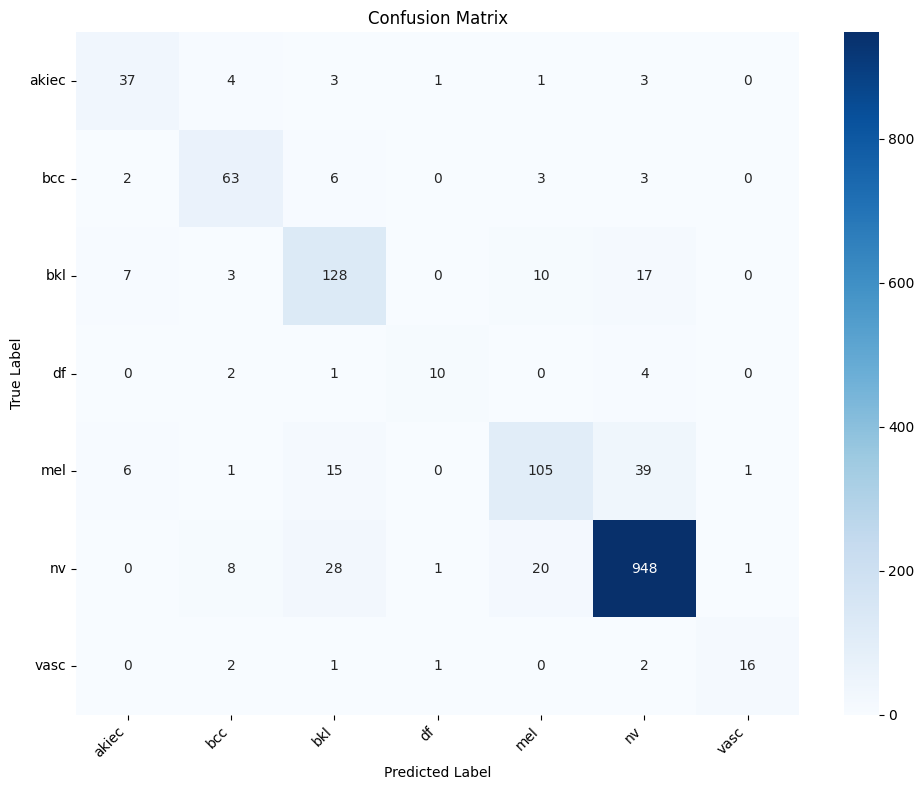

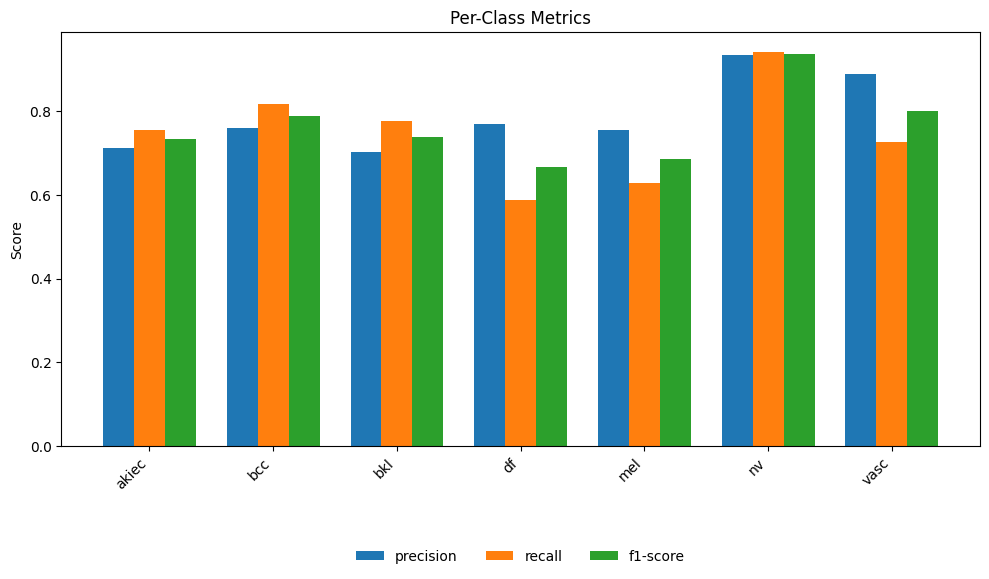

In [16]:
import os, torch, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import pandas as pd

# ==== Setup ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = os.path.join(CKPT_DIR, "PlantXViT_best.pth")

# ==== Load Model ====
if 'model' not in locals():
    model = PlantXViT_v2(num_classes=CFG["num_classes"]).to(device)

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt.get("model_state", ckpt), strict=False)
    print(f"✅ Loaded checkpoint: {ckpt_path}")
else:
    raise FileNotFoundError(f"❌ Checkpoint not found at {ckpt_path}")

model.eval()

all_preds = []
all_labels = []

# Evaluate on the test set to get all predictions and labels
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating Test Set", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda', enabled=CFG["use_amp"]):
            outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get class names
class_names = class_names # Use the globally defined class_names list

# Print Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Print Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Plot Confusion Matrix (optional)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Create df_report from classification_report output for plotting
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# ==== Plot Metric Bars ====
metrics = ["precision", "recall", "f1-score"]
plt.figure(figsize=(10, 6))

x = np.arange(len(class_names))
width = 0.25

for i, m in enumerate(metrics):
    plt.bar(x + i * width, df_report.iloc[:-3][m], width=width, label=m)

plt.xticks(x + width, class_names, rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Per-Class Metrics")

# --- Đưa legend ra ngoài hẳn, tụt xuống dưới ---
plt.legend(
    loc='upper center',        # căn giữa theo chiều ngang
    bbox_to_anchor=(0.5, -0.22),  # 0.5 là giữa trục x, -0.12 là khoảng cách tụt xuống
    ncol=3,                    # các nhãn nằm trên cùng 1 hàng
    frameon=False              # không có khung
)

plt.tight_layout()
plt.show()